In [ ]:
#1.Connecting the drive with kitti dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#2. Cloning into OpenPCDet which is from mmdettection and helps us run the pre trained Point Pillards libraray
import os

if not os.path.exists('OpenPCDet'):
    !git clone https://github.com/open-mmlab/OpenPCDet.git
%cd OpenPCDet

Cloning into 'OpenPCDet'...
remote: Enumerating objects: 4175, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 4175 (delta 0), reused 0 (delta 0), pack-reused 4170 (from 2)
Receiving objects: 100% (4175/4175), 4.21 MiB | 29.31 MiB/s, done.
Resolving deltas: 100% (2448/2448), done.
/content/OpenPCDet


In [ ]:
#3.Setting up the environment for execution of the mmdet libray
import os

print("1. Installing CUDA 11.8...")
!apt-get update > /dev/null
!apt-get install -y cuda-toolkit-11-8 > /dev/null
os.environ["CUDA_HOME"] = "/usr/local/cuda-11.8"

print("\n2. Installing PyTorch cu118...")
!pip install torch==2.2.1 torchvision==0.17.1 torchaudio==2.2.1 --index-url https://download.pytorch.org/whl/cu118 > /dev/null

print("\n3. Installing spconv and cumm...")
!pip uninstall -y spconv spconv-cu118 cumm cumm-cu118 > /dev/null
!pip install --upgrade cumm-cu118 spconv-cu118 > /dev/null

# Disable JIT to prevent compilation errors
os.environ["SPCONV_DISABLE_JIT"] = "1"
os.environ["CUMM_DISABLE_JIT"] = "1"

print("\n4. Setting up OpenPCDet...")
if not os.path.exists('/content/OpenPCDet'):
    !git clone https://github.com/open-mmlab/OpenPCDet.git

!pip install tensorboardX easydict pyyaml scikit-image tqdm SharedArray numba > /dev/null
!cd /content/OpenPCDet && pip install av2 && pip install -r requirements.txt > /dev/null
!cd /content/OpenPCDet && python setup.py develop

# Fix for NumPy 2.0 compatibility issues - enforced at the end
print("\nInstalling compatible NumPy version (1.26.4)...")
!pip install "numpy<2.0.0" --force-reinstall > /dev/null
!pip install open3d
print("\n5. Testing spconv import...")
import spconv
print("spconv installed successfully! Version:", spconv.__version__)

1. Installing CUDA 11.8...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%

2. Installing PyTorch cu118...

3. Installing spconv and cumm...

4. Setting up OpenPCDet...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 111.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 115.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 144.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━


5. Testing spconv import...
spconv installed successfully! Version: 2.3.8


In [ ]:
#3. Setting up the environment
import os
import shutil

# Replace 'path_to_kitti' with your actual path in Drive
drive_kitti_path = '/content/drive/MyDrive/Kitti_tracking'
local_kitti_path = '/content/OpenPCDet/data/kitti'

os.makedirs('/content/OpenPCDet/data', exist_ok=True)

# Remove existing local_kitti_path if it's not a symlink or if it's a broken symlink
if os.path.exists(local_kitti_path):
    if os.path.islink(local_kitti_path) or os.path.isdir(local_kitti_path):
        print(f"Removing existing {local_kitti_path}")
        if os.path.islink(local_kitti_path):
            os.unlink(local_kitti_path)
        else:
            shutil.rmtree(local_kitti_path)

# Create a new symlink
if not os.path.exists(local_kitti_path):
    os.symlink(drive_kitti_path, local_kitti_path)
    print("Symlink created for KITTI dataset.")
else:
    print("KITTI dataset path already exists and is valid.")

# Verify the symlink content by listing some directories
print(f"Verifying contents of {local_kitti_path}/training:")
if os.path.exists(os.path.join(local_kitti_path, 'training')):
    print(os.listdir(os.path.join(local_kitti_path, 'training')))
else:
    print(f"Directory not found: {local_kitti_path}/training")


Removing existing /content/OpenPCDet/data/kitti
Symlink created for KITTI dataset.
Verifying contents of /content/OpenPCDet/data/kitti/training:
['calib', 'label_02', 'image_02', 'velodyne']


In [ ]:
import os
import glob
import shutil
from tqdm import tqdm

# Paths
drive_kitti_path = '/content/drive/MyDrive/Kitti_tracking'
src_base = '/content/OpenPCDet/data/kitti_tracking'
dst_base = '/content/OpenPCDet/data/kitti_det_format'

# Create a stable symlink for the original tracking data
if not os.path.exists(src_base):
    if os.path.islink(src_base):
        os.unlink(src_base)
    os.symlink(drive_kitti_path, src_base)

# Clean up destination to avoid messy states from previous runs
if os.path.exists(dst_base):
    shutil.rmtree(dst_base)
os.makedirs(dst_base, exist_ok=True)
os.makedirs(os.path.join(dst_base, 'ImageSets'), exist_ok=True)

def process_tracking_label(label_path, dst_label_dir, seq_id):
    with open(label_path, 'r') as f:
        lines = f.readlines()

    frame_dict = {}
    for line in lines:
        parts = line.strip().split(' ')
        if len(parts) < 15: continue

        frame_idx = int(parts[0])
        det_line = ' '.join([parts[2]] + parts[3:]) + '\n'

        if frame_idx not in frame_dict:
            frame_dict[frame_idx] = []
        frame_dict[frame_idx].append(det_line)

    for frame_idx, det_lines in frame_dict.items():
        global_idx = f"{int(seq_id):04d}{frame_idx:04d}"
        out_path = os.path.join(dst_label_dir, f"{global_idx}.txt")

        # OpenPCDet bug fix: DontCare objects MUST be at the bottom of the file
        det_lines.sort(key=lambda x: 1 if x.startswith('DontCare') else 0)

        with open(out_path, 'w') as f:
            f.writelines(det_lines)

def convert_tracking_to_detection(split='training'):
    print(f"Converting {split} set...")
    src_split = os.path.join(src_base, split)
    dst_split = os.path.join(dst_base, split)

    src_velo = os.path.join(src_split, 'velodyne')
    src_image = os.path.join(src_split, 'image_02')
    src_calib = os.path.join(src_split, 'calib')
    src_label = os.path.join(src_split, 'label_02')

    dst_velo = os.path.join(dst_split, 'velodyne')
    dst_image = os.path.join(dst_split, 'image_2')
    dst_calib = os.path.join(dst_split, 'calib')
    dst_label = os.path.join(dst_split, 'label_2')

    for d in [dst_velo, dst_image, dst_calib, dst_label]:
        os.makedirs(d, exist_ok=True)

    if not os.path.exists(src_velo):
        print(f"Source velodyne not found: {src_velo}")
        return

    seqs = sorted(os.listdir(src_velo))

    train_frames = []
    val_frames = []

    for seq in tqdm(seqs, desc=f"Processing {split} sequences"):
        if not os.path.isdir(os.path.join(src_velo, seq)): continue

        # First extract known labels
        if split == 'training' and os.path.exists(os.path.join(src_label, f"{seq}.txt")):
            process_tracking_label(os.path.join(src_label, f"{seq}.txt"), dst_label, seq)

        velo_files = sorted(glob.glob(os.path.join(src_velo, seq, '*.bin')))
        for vf in velo_files:
            frame_idx = os.path.basename(vf).replace('.bin', '')
            global_idx = f"{int(seq):04d}{int(frame_idx):04d}"

            src_imgf = os.path.join(src_image, seq, f"{frame_idx}.png")
            src_calf = os.path.join(src_calib, f"{seq}.txt")

            # Strict source check: skip if critical files missing
            if not os.path.exists(src_imgf) or not os.path.exists(src_calf):
                continue

            # Make symlinks
            dst_vf = os.path.join(dst_velo, f"{global_idx}.bin")
            if not os.path.exists(dst_vf):
                os.symlink(vf, dst_vf)

            dst_imgf = os.path.join(dst_image, f"{global_idx}.png")
            if not os.path.exists(dst_imgf):
                os.symlink(src_imgf, dst_imgf)

            dst_calf = os.path.join(dst_calib, f"{global_idx}.txt")
            if not os.path.exists(dst_calf):
                os.symlink(src_calf, dst_calf)

            # Ensure label file exists
            if split == 'training':
                dst_label_file = os.path.join(dst_label, f"{global_idx}.txt")
                if not os.path.exists(dst_label_file) or os.path.getsize(dst_label_file) == 0:
                    with open(dst_label_file, 'w') as f:
                        f.write("DontCare -1 -1 -10 0.0 0.0 10.0 10.0 -1 -1 -1 -1000 -1000 -1000 -10\n")

            # Route frames to train (0-16) or val (17-20)
            if int(seq) >= 17:
                val_frames.append(global_idx)
            else:
                train_frames.append(global_idx)

    # --- SPEED HACK: Put only 1 frame in train.txt so we skip massive train pkl generation ---
    with open(os.path.join(dst_base, 'ImageSets', 'train.txt'), 'w') as f:
        if train_frames:
            f.write(train_frames[0] + '\n')

    with open(os.path.join(dst_base, 'ImageSets', 'val.txt'), 'w') as f:
        f.write('\n'.join(val_frames) + '\n')

    print(f"\nCreated splits: 1 training frame (SPEED HACK) and {len(val_frames)} validation frames (Seq 17-20).")

convert_tracking_to_detection('training')
print(f"\nConversion complete! Flat dataset ready at: {dst_base}")


Converting training set...


Processing training sequences: 100%|██████████| 21/21 [00:29<00:00,  1.43s/it]


Created splits: 1 training frame (SPEED HACK) and 2380 validation frames (Seq 17-20).

Conversion complete! Flat dataset ready at: /content/OpenPCDet/data/kitti_det_format


In [ ]:
#fix to avoid using JIT as it causes issues while execution.
import os

so3_file_path = '/content/OpenPCDet/pcdet/datasets/argo2/argo2_utils/so3.py'

# Read the content of the file
with open(so3_file_path, 'r') as f:
    lines = f.readlines()

# Modify the lines to comment out @torch.jit.script
modified_lines = []
for line in lines:
    if '@torch.jit.script' in line:
        modified_lines.append('# ' + line)  # Comment out the line
    else:
        modified_lines.append(line)

# Write the modified content back to the file
with open(so3_file_path, 'w') as f:
    f.writelines(modified_lines)

print(f"Modified {so3_file_path} to comment out @torch.jit.script.")

Modified /content/OpenPCDet/pcdet/datasets/argo2/argo2_utils/so3.py to comment out @torch.jit.script.


In [ ]:
import os
import shutil

cumm_include_path = '/usr/local/lib/python3.12/dist-packages/cumm/build/core_cc/include'
current_cplus_include_path = os.environ.get('CPLUS_INCLUDE_PATH', '')
os.environ['CPLUS_INCLUDE_PATH'] = f"{cumm_include_path}:{current_cplus_include_path}"

print(f"CPLUS_INCLUDE_PATH set to: {os.environ['CPLUS_INCLUDE_PATH']}")

# Revert the YAML config to its original state (using default data/kitti)
!cd /content/OpenPCDet && git checkout tools/cfgs/dataset_configs/kitti_dataset.yaml

local_kitti_path = '/content/OpenPCDet/data/kitti'
flat_dataset_path = '/content/OpenPCDet/data/kitti_det_format'

# Remove existing data/kitti symlink or folder
if os.path.exists(local_kitti_path):
    if os.path.islink(local_kitti_path):
        os.unlink(local_kitti_path)
    else:
        shutil.rmtree(local_kitti_path)

# Create a symlink so data/kitti points to our flat dataset
os.symlink(flat_dataset_path, local_kitti_path)
print(f"\nSymlinked {flat_dataset_path} to {local_kitti_path}")

imagesets_path = os.path.join(local_kitti_path, 'ImageSets')
print(f"Verifying contents of {imagesets_path}:")
if os.path.exists(imagesets_path):
    print(os.listdir(imagesets_path))
else:
    print(f"Directory not found: {imagesets_path}")

# Generate the required .pkl files for OpenPCDet
print("\nGenerating KITTI info pkl files...")
!cd /content/OpenPCDet && python -m pcdet.datasets.kitti.kitti_dataset create_kitti_infos tools/cfgs/dataset_configs/kitti_dataset.yaml


CPLUS_INCLUDE_PATH set to: /usr/local/lib/python3.12/dist-packages/cumm/build/core_cc/include:/usr/local/lib/python3.12/dist-packages/cumm/build/core_cc/include:
Updated 0 paths from the index

Symlinked /content/OpenPCDet/data/kitti_det_format to /content/OpenPCDet/data/kitti
Verifying contents of /content/OpenPCDet/data/kitti/ImageSets:
['val.txt', 'train.txt']

Generating KITTI info pkl files...
<frozen runpy>:128: RuntimeWarning: 'pcdet.datasets.kitti.kitti_dataset' found in sys.modules after import of package 'pcdet.datasets.kitti', but prior to execution of 'pcdet.datasets.kitti.kitti_dataset'; this may result in unpredictable behaviour
---------------Start to generate data infos---------------
train sample_idx: 00000000
Kitti info train file is saved to /content/OpenPCDet/data/kitti/kitti_infos_train.pkl
val sample_idx: 00170000
val sample_idx: 00170001
val sample_idx: 00170002
val sample_idx: 00170003
val sample_idx: 00170004
val sample_idx: 00170005
val sample_idx: 00170006
va

In [ ]:
import shutil
import glob
import os
# Source path where the pkl files are generated
source_dir = '/content/OpenPCDet/data/kitti'
# Destination path in your Google Drive (adjust if needed)
drive_backup_dir = '/content/drive/MyDrive/Kitti_tracking/pkl_backups'

os.makedirs(drive_backup_dir, exist_ok=True)

# Find all generated pkl files
pkl_files = glob.glob(os.path.join(source_dir, '*.pkl'))

if not pkl_files:
    print("No .pkl files found. Make sure you run the generation cell first!")
else:
    for pkl_file in pkl_files:
        file_name = os.path.basename(pkl_file)
        dest_path = os.path.join(drive_backup_dir, file_name)
        print(f"Copying {file_name} to Drive...")
        shutil.copy2(pkl_file, dest_path)
    print(f"\nSuccessfully backed up {len(pkl_files)} .pkl files to {drive_backup_dir}!")


Copying kitti_infos_val.pkl to Drive...
Copying kitti_infos_trainval.pkl to Drive...
Copying kitti_infos_train.pkl to Drive...

Successfully backed up 3 .pkl files to /content/drive/MyDrive/Kitti_tracking/pkl_backups!


In [ ]:
import os
import shutil
import glob

local_kitti_path = '/content/OpenPCDet/data/kitti'
flat_dataset_path = '/content/OpenPCDet/data/kitti_det_format'
drive_backup_dir = '/content/drive/MyDrive/Kitti_tracking/pkl_backups'

print("1. Restoring correct dataset symlink...")
if os.path.exists(local_kitti_path):
    if os.path.islink(local_kitti_path):
        os.unlink(local_kitti_path)
    else:
        shutil.rmtree(local_kitti_path)

if os.path.exists(flat_dataset_path):
    os.symlink(flat_dataset_path, local_kitti_path)
    print(f"Symlinked {flat_dataset_path} -> {local_kitti_path}")

    print("\n2. Restoring .pkl files from Google Drive backup...")
    pkl_files = glob.glob(os.path.join(drive_backup_dir, '*.pkl'))
    if not pkl_files:
        print(f"\u274c Warning: No .pkl files found in {drive_backup_dir}!")
    else:
        for pkl in pkl_files:
            dest = os.path.join(local_kitti_path, os.path.basename(pkl))
            shutil.copy2(pkl, dest)
            print(f"Restored {os.path.basename(pkl)}")

    print("\n\u2705 Restoration complete! You can now run the evaluation cell.")
else:
    print(f"\n\u274c Error: {flat_dataset_path} not found.")
    print("\u27a1\ufe0f ACTION REQUIRED: You need to run the conversion cell (6b162445) first to rebuild the dataset folder!")


1. Restoring correct dataset symlink...
Symlinked /content/OpenPCDet/data/kitti_det_format -> /content/OpenPCDet/data/kitti

2. Restoring .pkl files from Google Drive backup...
Restored kitti_infos_train.pkl
Restored kitti_infos_val.pkl
Restored kitti_infos_trainval.pkl

✅ Restoration complete! You can now run the evaluation cell.


In [ ]:

import os
import glob
import shutil

# Evaluation on validation dataset using pretrained pointpillar file
%cd /content/OpenPCDet/tools

# Please download the pre-trained PointPillar weights from OpenPCDet's Model Zoo
# and place them in your Google Drive, then update the path below.
ckpt_path = '/content/drive/MyDrive/kitti/pointrcnn_7870.pth'

# Command to run evaluation on the KITTI validation set.
!python test.py --cfg_file cfgs/kitti_models/pointrcnn.yaml --batch_size 4 --ckpt {ckpt_path} --save_to_file

# --- Automatically Backup Results and Logs to Drive ---
print("\n--- Backing up Results to Google Drive ---")
output_dir = '/content/OpenPCDet/output'
drive_pred_dir = '/content/drive/MyDrive/Kitti_tracking/predictions'
os.makedirs(drive_pred_dir, exist_ok=True)

# Backup result.pkl
result_files = glob.glob(os.path.join(output_dir, '**', 'result.pkl'), recursive=True)
if result_files:
    result_files.sort(key=os.path.getmtime, reverse=True)
    latest_result = result_files[0]
    shutil.copy2(latest_result, os.path.join(drive_pred_dir, 'pointrcnn_result.pkl'))
    shutil.copy2(latest_result, '/content/pointrcnn_result.pkl')
    print("\u2705 Saved pointrcnn_result.pkl to Drive and /content/")
else:
    print("\u274c No result.pkl found to backup.")

# Backup evaluation logs
log_files = glob.glob(os.path.join(output_dir, '**', 'log_eval_*.txt'), recursive=True)
if log_files:
    log_files.sort(key=os.path.getmtime, reverse=True)
    latest_log = log_files[0]
    log_filename = os.path.basename(latest_log)
    shutil.copy2(latest_log, os.path.join(drive_pred_dir, f"point_rcnn_{log_filename}"))
    shutil.copy2(latest_log, f'/content/{log_filename}')
    print(f"\u2705 Saved log {log_filename} to Drive and /content/")
else:
    print("\u274c No evaluation logs found to backup.")


/content/OpenPCDet/tools
/content/OpenPCDet/tools/../pcdet/ops/pointnet2/pointnet2_batch/pointnet2_modules.py:26: SyntaxWarning: invalid escape sequence '\s'
  new_features: (B, npoint, \sum_k(mlps[k][-1])) tensor of the new_features descriptors
/content/OpenPCDet/tools/../pcdet/ops/pointnet2/pointnet2_stack/pointnet2_modules.py:87: SyntaxWarning: invalid escape sequence '\s'
  new_features: (M1 + M2 ..., \sum_k(mlps[k][-1])) tensor of the new_features descriptors
/content/OpenPCDet/tools/../pcdet/ops/pointnet2/pointnet2_stack/pointnet2_modules.py:392: SyntaxWarning: invalid escape sequence '\s'
  new_features: (M1 + M2 ..., \sum_k(mlps[k][-1])) tensor of the new_features descriptors
/content/OpenPCDet/tools/../pcdet/ops/pointnet2/pointnet2_stack/voxel_pool_modules.py:81: SyntaxWarning: invalid escape sequence '\s'
  new_features: (M1 + M2 ..., \sum_k(mlps[k][-1])) tensor of the new_features descriptors
2026-03-28 08:49:46,552   INFO  **********************Start logging****************

In [ ]:
!pip install av2


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 112.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.0
    Uninstalling numpy-1.26.0:
      Successfully uninstalled numpy-1.26.0


In [ ]:
!pip install numpy==1.26



  Using cached numpy-1.26.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (58 kB)
Using cached numpy-1.26.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.0 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.0 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-python 

## Extract Sequential Predictions



In [ ]:
import pickle
import glob
import os
import numpy as np

class CustomUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'numpy.core.multiarray':
            module = 'numpy._core.multiarray'
        return super().find_class(module, name)

# Load ground truth
gt_path = '/content/OpenPCDet/data/kitti/kitti_infos_val.pkl'
try:
    with open(gt_path, 'rb') as f:
        gt_infos = CustomUnpickler(f).load()
    print(f"Successfully loaded ground truth from {gt_path}")
except FileNotFoundError:
    print(f"Ground truth file {gt_path} not found.")
except Exception as e:
    print(f"Failed to load {gt_path}: {e}")

# Find the prediction results file
result_files = glob.glob('/content/pointrcnn_result.pkl', recursive=True)
pred_path = result_files[0] if result_files else 'results.pkl'

if os.path.exists(pred_path):
    try:
        with open(pred_path, 'rb') as f:
            pred_infos = CustomUnpickler(f).load()
        print(f"Loaded predictions from {pred_path}")
    except Exception as e:
        print(f"Failed to load predictions: {e}")
else:
    print(f"Prediction file {pred_path} not found.")


Successfully loaded ground truth from /content/OpenPCDet/data/kitti/kitti_infos_val.pkl
Loaded predictions from /content/pointrcnn_result.pkl


Found log file: /content/OpenPCDet/output/kitti_models/pointrcnn/default/eval/epoch_7870/val/default/log_eval_20260328-084946.txt


,Class,Difficulty,AP Type,AP
0,Car,Easy,3D,91.5155
1,Car,Moderate,3D,84.8260
2,Car,Hard,3D,80.0716
3,Car,Easy,BEV,91.7146
4,Car,Moderate,BEV,88.1792
5,Car,Hard,BEV,85.5180
6,Pedestrian,Easy,3D,63.5846
7,Pedestrian,Moderate,3D,61.6615
8,Pedestrian,Hard,3D,55.1428
9,Pedestrian,Easy,BEV,67.2551


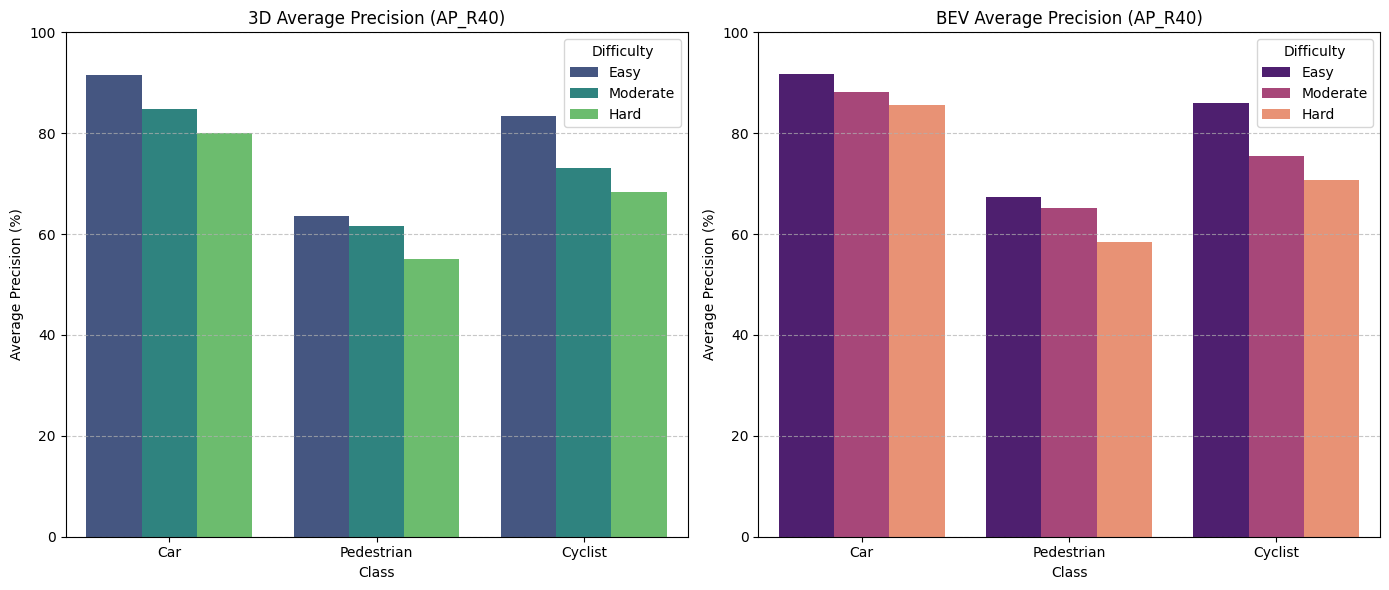

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pandas as pd

def parse_log_and_plot(log_path):
    """
    Parses the log file to extract 3D and BEV AP_R40 metrics and plots them.
    Assumes standard OpenPCDet evaluation output format.
    """
    try:
        with open(log_path, 'r') as f:
            log_content = f.read()
    except FileNotFoundError:
        print(f"Error: Log file not found at {log_path}")
        return

    # Define the specific headers for each class according to AP_R40
    headers = {
        'Car': r'Car AP_R40@0.70, 0.70, 0.70:(.*?)(?=\n\n|\Z)',
        'Pedestrian': r'Pedestrian AP_R40@0.50, 0.50, 0.50:(.*?)(?=\n\n|\Z)',
        'Cyclist': r'Cyclist AP_R40@0.50, 0.50, 0.50:(.*?)(?=\n\n|\Z)'
    }

    metrics_data = []

    # Parse the log content
    for cls, pattern in headers.items():
        cls_match = re.search(pattern, log_content, re.DOTALL)

        if cls_match:
            block = cls_match.group(1)

            # Extract 3d AP
            ap_3d_match = re.search(r"3d\s+AP:([\d\.]+),\s*([\d\.]+),\s*([\d\.]+)", block)
            if ap_3d_match:
                easy, moderate, hard = map(float, ap_3d_match.groups())
                for diff, val in zip(['Easy', 'Moderate', 'Hard'], [easy, moderate, hard]):
                    metrics_data.append({'Class': cls, 'Difficulty': diff, 'AP Type': '3D', 'AP': val})

            # Extract bev AP
            ap_bev_match = re.search(r"bev\s+AP:([\d\.]+),\s*([\d\.]+),\s*([\d\.]+)", block)
            if ap_bev_match:
                easy, moderate, hard = map(float, ap_bev_match.groups())
                for diff, val in zip(['Easy', 'Moderate', 'Hard'], [easy, moderate, hard]):
                    metrics_data.append({'Class': cls, 'Difficulty': diff, 'AP Type': 'BEV', 'AP': val})

    if not metrics_data:
        print("No matching 3D/BEV metrics found in the log file. Please check the log format.")
        return

    df = pd.DataFrame(metrics_data)
    display(df)

    # Plotting
    plt.figure(figsize=(14, 6))

    # Subplot for 3D AP
    plt.subplot(1, 2, 1)
    sns.barplot(data=df[df['AP Type'] == '3D'], x='Class', y='AP', hue='Difficulty', palette='viridis')
    plt.title('3D Average Precision (AP_R40)')
    plt.ylabel('Average Precision (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Subplot for BEV AP
    plt.subplot(1, 2, 2)
    sns.barplot(data=df[df['AP Type'] == 'BEV'], x='Class', y='AP', hue='Difficulty', palette='magma')
    plt.title('BEV Average Precision (AP_R40)')
    plt.ylabel('Average Precision (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Input path here. Change to your actual log file path.
log_file_path = '/content/OpenPCDet/output/kitti_models/pointrcnn/default/eval/epoch_7870/val/default/log_eval_20260328-084946.txt'

# Find and parse the log file
import glob
matched_files = glob.glob(log_file_path)
if matched_files:
    # Pick the most recent one or the only one
    exact_log_path = matched_files[-1]
    print(f"Found log file: {exact_log_path}")
    parse_log_and_plot(exact_log_path)
else:
    print(f"Could not find log files matching {log_file_path}. Please update the path.")


In [ ]:
def calculate_iou_2d(box1, box2):
    """
    Calculate the 2D Intersection over Union (IoU) of two bounding boxes.

    Parameters:
    box1 (list or tuple): [x_min, y_min, x_max, y_max]
    box2 (list or tuple): [x_min, y_min, x_max, y_max]

    Returns:
    float: IoU value
    """
    # Determine the coordinates of the intersection rectangle
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    # Calculate the area of intersection rectangle
    intersection_area = max(0, x_right - x_left) * max(0, y_bottom - y_top)

    # Calculate the area of both bounding boxes
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # Calculate the union area
    union_area = box1_area + box2_area - intersection_area

    # Compute the Intersection over Union
    if union_area == 0:
        return 0.0

    iou = intersection_area / union_area
    return iou

print("Defined calculate_iou_2d function.")


Defined calculate_iou_2d function.


In [ ]:
def extract_prediction_matches(pred_infos, gt_infos, target_class='Car', iou_threshold=0.5):
    results = []
    num_frames = min(len(pred_infos), len(gt_infos))

    for i in range(num_frames):
        pred = pred_infos[i]
        gt = gt_infos[i]

        if 'name' in pred and 'bbox' in pred and 'score' in pred:
            pred_names = pred['name']
            pred_bboxes = pred['bbox']
            pred_scores = pred['score']
        else:
            continue

        class_mask = pred_names == target_class
        pred_bboxes_cls = pred_bboxes[class_mask]
        pred_scores_cls = pred_scores[class_mask]

        if 'annos' in gt and 'name' in gt['annos'] and 'bbox' in gt['annos']:
            gt_names = gt['annos']['name']
            gt_bboxes = gt['annos']['bbox']
        else:
            gt_names = np.array([])
            gt_bboxes = np.array([])

        gt_class_mask = gt_names == target_class
        gt_bboxes_cls = gt_bboxes[gt_class_mask]

        matched_gt = np.zeros(len(gt_bboxes_cls), dtype=bool)

        for pred_box, score in zip(pred_bboxes_cls, pred_scores_cls):
            best_iou = 0.0
            best_gt_idx = -1

            for j, gt_box in enumerate(gt_bboxes_cls):
                if matched_gt[j]:
                    continue
                iou = calculate_iou_2d(pred_box, gt_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = j

            if best_iou >= iou_threshold and best_gt_idx != -1:
                matched_gt[best_gt_idx] = True
                results.append({'score': score, 'tp': 1, 'fp': 0, 'iou': best_iou})
            else:
                results.append({'score': score, 'tp': 0, 'fp': 1, 'iou': best_iou})

    return results

prediction_matches = extract_prediction_matches(pred_infos, gt_infos, target_class='Car', iou_threshold=0.5)
print(f"Extracted {len(prediction_matches)} prediction matches.")
if len(prediction_matches) > 0:
    print(f"Sample match: {prediction_matches[0]}")

Extracted 9181 prediction matches.
Sample match: {'score': 0.1197089, 'tp': 0, 'fp': 1, 'iou': 0.0}


In [ ]:
import numpy as np

def evaluate_class_2d(target_class, prediction_matches, gt_infos):
    # 1. Calculate total ground truth boxes for the target class
    total_gt = 0
    for gt in gt_infos:
        if 'annos' in gt and 'name' in gt['annos']:
            gt_names = gt['annos']['name']
            total_gt += np.sum(gt_names == target_class)

    # Handle edge case: no ground truth or predictions
    if total_gt == 0 or len(prediction_matches) == 0:
        return {
            'AP': 0.0,
            'optimal_threshold': 0.0,
            'optimal_precision': 0.0,
            'optimal_recall': 0.0,
            'optimal_f1': 0.0,
            'optimal_avg_iou': 0.0,
            'recall_array': np.array([]),
            'precision_array': np.array([])
        }

    # 2. Sort prediction matches by score descending
    sorted_matches = sorted(prediction_matches, key=lambda x: x['score'], reverse=True)

    # 3. Extract tp, fp, scores, and ious
    tp_array = np.array([m['tp'] for m in sorted_matches])
    fp_array = np.array([m['fp'] for m in sorted_matches])
    scores_array = np.array([m['score'] for m in sorted_matches])

    # 4. Compute cumulative tp and fp
    cum_tp = np.cumsum(tp_array)
    cum_fp = np.cumsum(fp_array)

    # 5. Calculate precision and recall
    precision = cum_tp / (cum_tp + cum_fp)
    precision[np.isnan(precision)] = 0
    recall = cum_tp / total_gt

    # Make precision monotonically decreasing for AP calculation
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))
    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = np.maximum(mpre[i - 1], mpre[i])

    # Calculate AP
    i = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[i + 1] - mrec[i]) * mpre[i + 1])

    # 6. Compute F1-scores and find optimal threshold
    f1_scores = 2 * (precision * recall) / (precision + recall)
    f1_scores = np.nan_to_num(f1_scores, nan=0.0)
    optimal_idx = np.argmax(f1_scores)

    optimal_threshold = scores_array[optimal_idx]
    optimal_precision = precision[optimal_idx]
    optimal_recall = recall[optimal_idx]
    optimal_f1 = f1_scores[optimal_idx]

    # 7. Calculate average IoU for true positives >= optimal threshold
    filtered_matches = [m for m in sorted_matches if m['score'] >= optimal_threshold and m['tp'] == 1]
    tp_ious = [m['iou'] for m in filtered_matches]
    optimal_avg_iou = np.mean(tp_ious) if tp_ious else 0.0

    # 8. Return metrics dictionary
    return {
        'AP': ap,
        'optimal_threshold': optimal_threshold,
        'optimal_precision': optimal_precision,
        'optimal_recall': optimal_recall,
        'optimal_f1': optimal_f1,
        'optimal_avg_iou': optimal_avg_iou,
        'recall_array': recall,
        'precision_array': precision
    }

print("Defined evaluate_class_2d function.")


Defined evaluate_class_2d function.


Evaluating class: Car...
Evaluating class: Cyclist...
Evaluating class: Pedestrian...


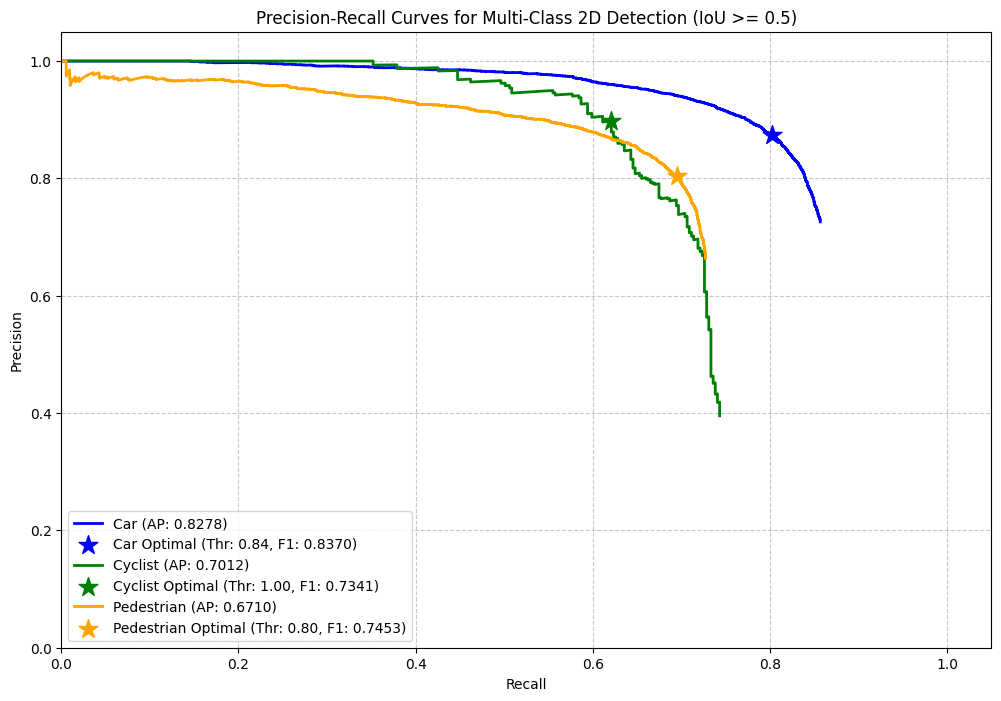


--- Multi-Class 2D Detection Summary (IoU >= 0.5) ---

Class: Car
  Average Precision (AP): 0.8278
  Optimal Confidence Threshold: 0.8442
  Precision at Optimal: 0.8747
  Recall at Optimal: 0.8024
  Max F1-score: 0.8370
  Average IoU at Optimal: 0.8892

Class: Cyclist
  Average Precision (AP): 0.7012
  Optimal Confidence Threshold: 0.9989
  Precision at Optimal: 0.8975
  Recall at Optimal: 0.6210
  Max F1-score: 0.7341
  Average IoU at Optimal: 0.7974

Class: Pedestrian
  Average Precision (AP): 0.6710
  Optimal Confidence Threshold: 0.7996
  Precision at Optimal: 0.8038
  Recall at Optimal: 0.6948
  Max F1-score: 0.7453
  Average IoU at Optimal: 0.7003


In [ ]:
import matplotlib.pyplot as plt

classes_to_evaluate = ['Car', 'Cyclist', 'Pedestrian']
all_class_metrics = {}

plt.figure(figsize=(12, 8))
colors = ['blue', 'green', 'orange']

for idx, cls in enumerate(classes_to_evaluate):
    print(f"Evaluating class: {cls}...")
    # Extract matches for the specific class
    matches = extract_prediction_matches(pred_infos, gt_infos, target_class=cls, iou_threshold=0.5)

    # Evaluate metrics
    metrics = evaluate_class_2d(cls, matches, gt_infos)
    all_class_metrics[cls] = metrics

    if metrics['recall_array'].size > 0 and metrics['precision_array'].size > 0:
        # Plot PR curve
        plt.plot(metrics['recall_array'], metrics['precision_array'], color=colors[idx],
                 label=f"{cls} (AP: {metrics['AP']:.4f})", linewidth=2)

        # Highlight optimal threshold
        plt.scatter(metrics['optimal_recall'], metrics['optimal_precision'], marker='*', s=200, color=colors[idx], zorder=5,
                    label=f"{cls} Optimal (Thr: {metrics['optimal_threshold']:.2f}, F1: {metrics['optimal_f1']:.4f})")
    else:
        print(f"No valid data to plot for {cls}.")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Multi-Class 2D Detection (IoU >= 0.5)')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.show()

# Print summary
print("\n--- Multi-Class 2D Detection Summary (IoU >= 0.5) ---")
for cls, m in all_class_metrics.items():
    print(f"\nClass: {cls}")
    print(f"  Average Precision (AP): {m['AP']:.4f}")
    print(f"  Optimal Confidence Threshold: {m['optimal_threshold']:.4f}")
    print(f"  Precision at Optimal: {m['optimal_precision']:.4f}")
    print(f"  Recall at Optimal: {m['optimal_recall']:.4f}")
    print(f"  Max F1-score: {m['optimal_f1']:.4f}")
    print(f"  Average IoU at Optimal: {m['optimal_avg_iou']:.4f}")

## Frame-by-Frame Temporal Analysis



In [ ]:
import numpy as np
import pandas as pd
import sys, os
import numpy as _np_check
if not _np_check.__version__.startswith('1.26'):
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           'numpy==1.26.4', '-q', '--force-reinstall'])
    print("numpy reinstalled – kernel will restart. Re-run this cell once.")
            # kills stale kernel, Colab auto-restarts
# ─── Per-frame metric computation ─────────────────────────────────────────
def compute_per_frame_metrics(pred_infos, gt_infos, class_thresholds, iou_threshold=0.5):
    """
    For every frame and every class, compute:
      tp, fp, fn, precision, recall, avg_iou, num_pred, num_gt.

    Uses the per-class optimal confidence threshold as the detection gate.
    Greedy IoU matching (highest-score prediction first).
    """
    records = []
    num_frames = min(len(pred_infos), len(gt_infos))

    for frame_idx in range(num_frames):
        pred = pred_infos[frame_idx]
        gt   = gt_infos[frame_idx]

        for cls, thr in class_thresholds.items():
            # --- Predictions above threshold ---
            if 'name' in pred and 'bbox' in pred and 'score' in pred:
                pmask        = (pred['name'] == cls) & (pred['score'] >= thr)
                pred_bboxes  = pred['bbox'][pmask]
                pred_scores  = pred['score'][pmask]
            else:
                pred_bboxes = np.empty((0, 4))
                pred_scores = np.array([])

            # --- Ground truth for this class ---
            if 'annos' in gt and 'name' in gt['annos'] and 'bbox' in gt['annos']:
                gmask      = gt['annos']['name'] == cls
                gt_bboxes  = gt['annos']['bbox'][gmask]
            else:
                gt_bboxes = np.empty((0, 4))

            num_gt   = len(gt_bboxes)
            num_pred = len(pred_bboxes)

            # Sort predictions by score descending for greedy matching
            sort_idx    = np.argsort(-pred_scores)
            pred_bboxes = pred_bboxes[sort_idx]

            matched_gt  = np.zeros(num_gt, dtype=bool)
            tp, fp      = 0, 0
            match_ious  = []

            for pb in pred_bboxes:
                best_iou, best_j = 0.0, -1
                for j, gb in enumerate(gt_bboxes):
                    if matched_gt[j]:
                        continue
                    iou = calculate_iou_2d(pb, gb)
                    if iou > best_iou:
                        best_iou, best_j = iou, j

                if best_iou >= iou_threshold and best_j != -1:
                    tp += 1
                    matched_gt[best_j] = True
                    match_ious.append(best_iou)
                else:
                    fp += 1

            fn        = num_gt - tp
            precision = tp / (tp + fp) if (tp + fp) > 0 else (1.0 if num_gt == 0 else 0.0)
            recall    = tp / num_gt    if num_gt  > 0 else np.nan   # undefined when no GT
            avg_iou   = float(np.mean(match_ious)) if match_ious else 0.0

            records.append({
                'frame_idx': frame_idx,
                'class'    : cls,
                'num_pred' : num_pred,
                'num_gt'   : num_gt,
                'tp'       : tp,
                'fp'       : fp,
                'fn'       : fn,
                'precision': precision,
                'recall'   : recall,
                'avg_iou'  : avg_iou,
            })

    return pd.DataFrame(records)


# Build thresholds dict from previously computed all_class_metrics
class_thresholds = {cls: m['optimal_threshold'] for cls, m in all_class_metrics.items()}

print("Per-class optimal confidence thresholds (from PR-curve F1 maximisation):")
for cls, thr in class_thresholds.items():
    print(f"  {cls:12s}: {thr:.4f}")

frame_metrics_df = compute_per_frame_metrics(
    pred_infos, gt_infos, class_thresholds, iou_threshold=0.5
)

print(f"\nComputed per-frame metrics for "
      f"{frame_metrics_df['frame_idx'].nunique()} frames  ×  "
      f"{frame_metrics_df['class'].nunique()} classes.")
print("\nSample (first 12 rows):")
print(frame_metrics_df.head(12).to_string(index=False))

Per-class optimal confidence thresholds (from PR-curve F1 maximisation):
  Car         : 0.8442
  Cyclist     : 0.9989
  Pedestrian  : 0.7996

Computed per-frame metrics for 2380 frames  ×  3 classes.

Sample (first 12 rows):
 frame_idx      class  num_pred  num_gt  tp  fp  fn  precision   recall  avg_iou
         0        Car         0       0   0   0   0   1.000000      NaN 0.000000
         0    Cyclist         0       1   0   0   1   0.000000 0.000000 0.000000
         0 Pedestrian         5       6   4   1   2   0.800000 0.666667 0.650168
         1        Car         0       0   0   0   0   1.000000      NaN 0.000000
         1    Cyclist         0       1   0   0   1   0.000000 0.000000 0.000000
         1 Pedestrian         5       6   4   1   2   0.800000 0.666667 0.576035
         2        Car         0       0   0   0   0   1.000000      NaN 0.000000
         2    Cyclist         0       1   0   0   1   0.000000 0.000000 0.000000
         2 Pedestrian         7       6   3  

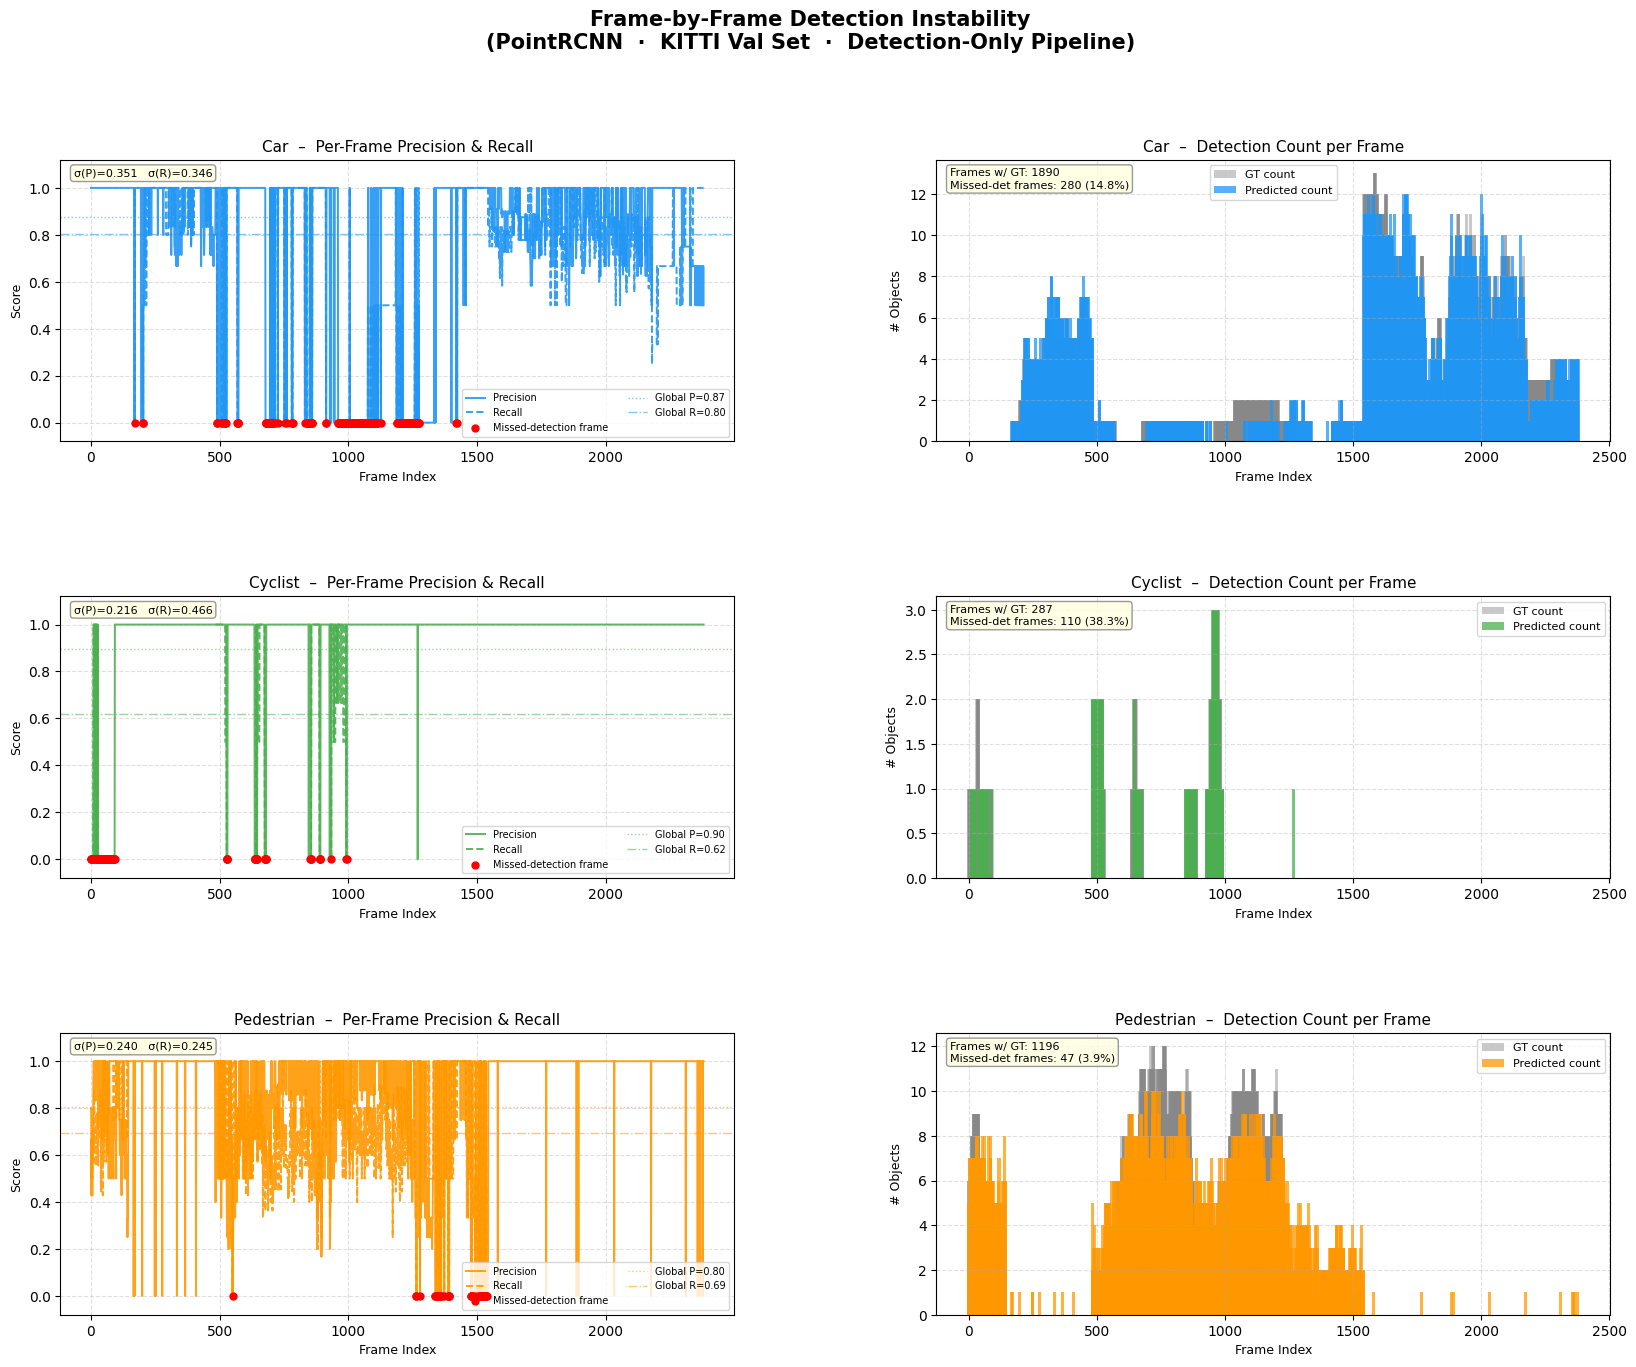


Plot saved to /content/frame_instability_timeseries.png

Observation: Both precision and recall exhibit substantial frame-to-frame
fluctuation. Red dots mark frames where objects existed but were entirely missed —
a direct indicator of the identity-inconsistency problem that tracking solves.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Time-series: Precision / Recall / Detection Count per frame ───────────
fig = plt.figure(figsize=(20, 15))
fig.suptitle(
    "Frame-by-Frame Detection Instability\n"
    "(PointRCNN  ·  KITTI Val Set  ·  Detection-Only Pipeline)",
    fontsize=15, fontweight='bold', y=0.98
)

classes  = ['Car', 'Cyclist', 'Pedestrian']
palette  = {'Car': '#2196F3', 'Cyclist': '#4CAF50', 'Pedestrian': '#FF9800'}
n_cols   = 2
gs       = gridspec.GridSpec(len(classes), n_cols, figure=fig,
                              hspace=0.55, wspace=0.30)

for row, cls in enumerate(classes):
    cls_df       = frame_metrics_df[frame_metrics_df['class'] == cls].sort_values('frame_idx')
    frames       = cls_df['frame_idx'].values
    prec         = cls_df['precision'].values
    rec          = cls_df['recall'].values        # NaN when num_gt == 0
    num_gt_arr   = cls_df['num_gt'].values
    num_pred_arr = cls_df['num_pred'].values
    color        = palette[cls]

    # ── Left: Precision & Recall over frames ────────────────────────────
    ax_pr = fig.add_subplot(gs[row, 0])
    ax_pr.plot(frames, prec, color=color, lw=1.4, label='Precision',  alpha=0.9)
    ax_pr.plot(frames, rec,  color=color, lw=1.4, label='Recall',
               linestyle='--', alpha=0.9)

    # Mark frames where GT objects exist but recall == 0 (missed detection)
    missed_mask = (num_gt_arr > 0) & (rec == 0)
    if missed_mask.any():
        ax_pr.scatter(frames[missed_mask], np.zeros(missed_mask.sum()),
                      color='red', s=25, zorder=6, label='Missed-detection frame')

    # Global reference lines (aggregate optimal from PR curve)
    gp = all_class_metrics[cls]['optimal_precision']
    gr = all_class_metrics[cls]['optimal_recall']
    ax_pr.axhline(gp, color=color, ls=':', lw=1.0, alpha=0.55,
                  label=f'Global P={gp:.2f}')
    ax_pr.axhline(gr, color=color, ls='-.', lw=1.0, alpha=0.55,
                  label=f'Global R={gr:.2f}')

    ax_pr.set_title(f'{cls}  –  Per-Frame Precision & Recall', fontsize=11)
    ax_pr.set_xlabel('Frame Index', fontsize=9)
    ax_pr.set_ylabel('Score', fontsize=9)
    ax_pr.set_ylim(-0.08, 1.12)
    ax_pr.legend(fontsize=7, loc='lower right', ncol=2)
    ax_pr.grid(True, ls='--', alpha=0.4)

    # Annotate σ values
    valid_rec = rec[~np.isnan(rec)]
    ax_pr.text(0.02, 0.97,
               f"σ(P)={prec.std():.3f}   σ(R)={valid_rec.std():.3f}",
               transform=ax_pr.transAxes, fontsize=8, va='top',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                         edgecolor='gray', alpha=0.8))

    # ── Right: Detection count (GT vs Predicted) ────────────────────────
    ax_cnt = fig.add_subplot(gs[row, 1])
    bar_w  = max(1.0, len(frames) / 200)
    ax_cnt.bar(frames, num_gt_arr,   color='#888888', alpha=0.45,
               width=bar_w, label='GT count')
    ax_cnt.bar(frames, num_pred_arr, color=color,    alpha=0.75,
               width=bar_w, label='Predicted count')

    ax_cnt.set_title(f'{cls}  –  Detection Count per Frame', fontsize=11)
    ax_cnt.set_xlabel('Frame Index', fontsize=9)
    ax_cnt.set_ylabel('# Objects', fontsize=9)
    ax_cnt.legend(fontsize=8)
    ax_cnt.grid(True, ls='--', alpha=0.4)

    # Compute and annotate missed-detection percentage
    frames_with_gt  = (num_gt_arr > 0).sum()
    missed_pct      = missed_mask.sum() / frames_with_gt * 100 if frames_with_gt > 0 else 0
    ax_cnt.text(0.02, 0.97,
                f"Frames w/ GT: {frames_with_gt}\nMissed-det frames: {missed_mask.sum()} ({missed_pct:.1f}%)",
                transform=ax_cnt.transAxes, fontsize=8, va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                          edgecolor='gray', alpha=0.8))

plt.savefig('/content/frame_instability_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved to /content/frame_instability_timeseries.png")
print("\nObservation: Both precision and recall exhibit substantial frame-to-frame")
print("fluctuation. Red dots mark frames where objects existed but were entirely missed —")
print("a direct indicator of the identity-inconsistency problem that tracking solves.")

## BEV Bounding-Box Visualisation – Consecutive Frames

Render a Bird's-Eye View of predictions vs ground truth for several **consecutive**
frames of the same driving sequence.  
* **Green boxes** = Ground Truth  
* **Red boxes** = PointRCNN predictions (above optimal threshold)


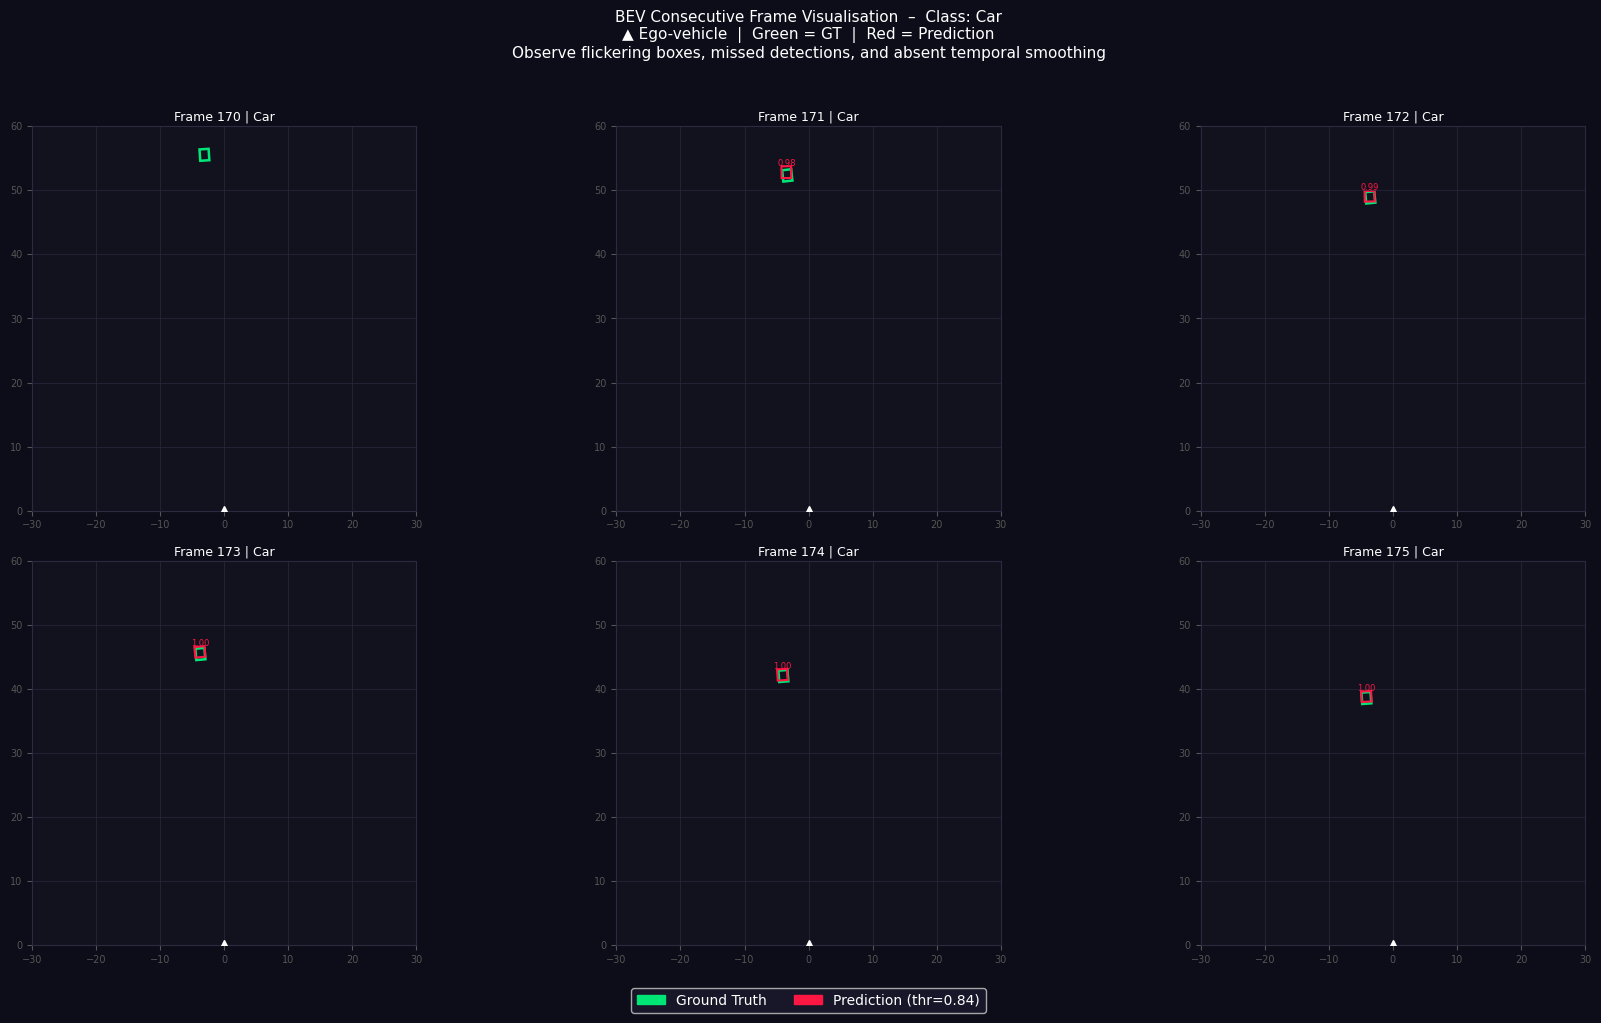

Plot saved to /content/bev_consecutive_frames.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


# ─── helpers ──────────────────────────────────────────────────────────────
def _bev_corners(cx, cz, length, width, heading):
    """Return 4 corners of a rotated box in the BEV (camera X-Z) plane."""
    c, s = np.cos(heading), np.sin(heading)
    offsets = np.array([[ length/2,  width/2],
                         [-length/2,  width/2],
                         [-length/2, -width/2],
                         [ length/2, -width/2]])
    R = np.array([[c, -s], [s, c]])
    rotated = (R @ offsets.T).T
    rotated[:, 0] += cx
    rotated[:, 1] += cz
    return rotated


def draw_bev_box(ax, cx, cz, length, width, heading,
                 color, lw=1.5, alpha=1.0, label_score=None):
    corners = _bev_corners(cx, cz, length, width, heading)
    poly    = plt.Polygon(corners, closed=True, fill=False,
                          edgecolor=color, linewidth=lw, alpha=alpha)
    ax.add_patch(poly)
    if label_score is not None:
        ax.text(cx, cz + 0.6, f'{label_score:.2f}',
                color=color, fontsize=6, ha='center', va='bottom')


def plot_bev_frame(ax, pred, gt, cls, threshold, frame_idx,
                   x_range=(-30, 30), z_range=(0, 60)):
    """
    BEV top-down view for one frame.
    Camera frame:  x=right, y=down, z=forward.
    BEV:           horizontal = x (camera),  vertical = z (camera).
    """
    ax.set_facecolor('#12121f')
    ax.set_xlim(*x_range)
    ax.set_ylim(*z_range)
    ax.set_aspect('equal')
    ax.grid(True, color='#2a2a40', linewidth=0.5)
    ax.set_title(f'Frame {frame_idx} | {cls}', color='white',
                 fontsize=9, pad=4)
    ax.tick_params(colors='#555555', labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2a40')

    # ── Ground Truth ──────────────────────────────────────────────────────
    if 'annos' in gt and 'name' in gt['annos']:
        gmask = gt['annos']['name'] == cls
        if gmask.sum() > 0 and 'location' in gt['annos']:
            locs = gt['annos']['location'][gmask]    # (N,3): cam x,y,z
            dims = gt['annos']['dimensions'][gmask]  # (N,3): h,w,l
            rots = gt['annos']['rotation_y'][gmask]
            for loc, dim, rot in zip(locs, dims, rots):
                draw_bev_box(ax, loc[0], loc[2],
                             dim[2], dim[1], rot,
                             color='#00e676', lw=1.8)

    # ── Predictions ───────────────────────────────────────────────────────
    if 'name' in pred and 'score' in pred and 'location' in pred:
        pmask = (pred['name'] == cls) & (pred['score'] >= threshold)
        if pmask.sum() > 0:
            locs   = pred['location'][pmask]
            dims   = pred['dimensions'][pmask]
            rots   = pred['rotation_y'][pmask]
            scores = pred['score'][pmask]
            for loc, dim, rot, sc in zip(locs, dims, rots, scores):
                draw_bev_box(ax, loc[0], loc[2],
                             dim[2], dim[1], rot,
                             color='#ff1744', lw=1.5,
                             label_score=sc)

    # Ego-vehicle marker
    ax.plot(0, 0, marker='^', color='white', ms=7, zorder=10)


# ── Choose class and consecutive window ───────────────────────────────────
vis_class = 'Car'   # Change to 'Pedestrian' or 'Cyclist' as desired
N_SHOW    = 6
thr       = class_thresholds[vis_class]

# Find the first N_SHOW consecutive frames that contain GT objects
has_gt = frame_metrics_df[
    (frame_metrics_df['class'] == vis_class) &
    (frame_metrics_df['num_gt'] > 0)
]['frame_idx'].sort_values().values

if len(has_gt) >= N_SHOW:
    start       = int(has_gt[0])
    vis_frames  = list(range(start, start + N_SHOW))
else:
    vis_frames  = list(range(min(N_SHOW, len(pred_infos))))

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#0d0d1a')
axes_flat = axes.flatten()

for ax_i, fid in enumerate(vis_frames):
    fid = min(fid, len(pred_infos) - 1)
    plot_bev_frame(axes_flat[ax_i],
                   pred_infos[fid], gt_infos[fid],
                   vis_class, thr, fid)

gt_patch   = mpatches.Patch(color='#00e676', label='Ground Truth')
pred_patch = mpatches.Patch(color='#ff1744', label=f'Prediction (thr={thr:.2f})')

fig.legend(handles=[gt_patch, pred_patch], loc='lower center',
           ncol=2, fontsize=10, facecolor='#1a1a2e', labelcolor='white',
           framealpha=0.8, bbox_to_anchor=(0.5, 0.01))

fig.suptitle(
    f"BEV Consecutive Frame Visualisation  –  Class: {vis_class}\n"
    "▲ Ego-vehicle  |  Green = GT  |  Red = Prediction\n"
    "Observe flickering boxes, missed detections, and absent temporal smoothing",
    color='white', fontsize=11, y=1.02
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('/content/bev_consecutive_frames.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print("Plot saved to /content/bev_consecutive_frames.png")

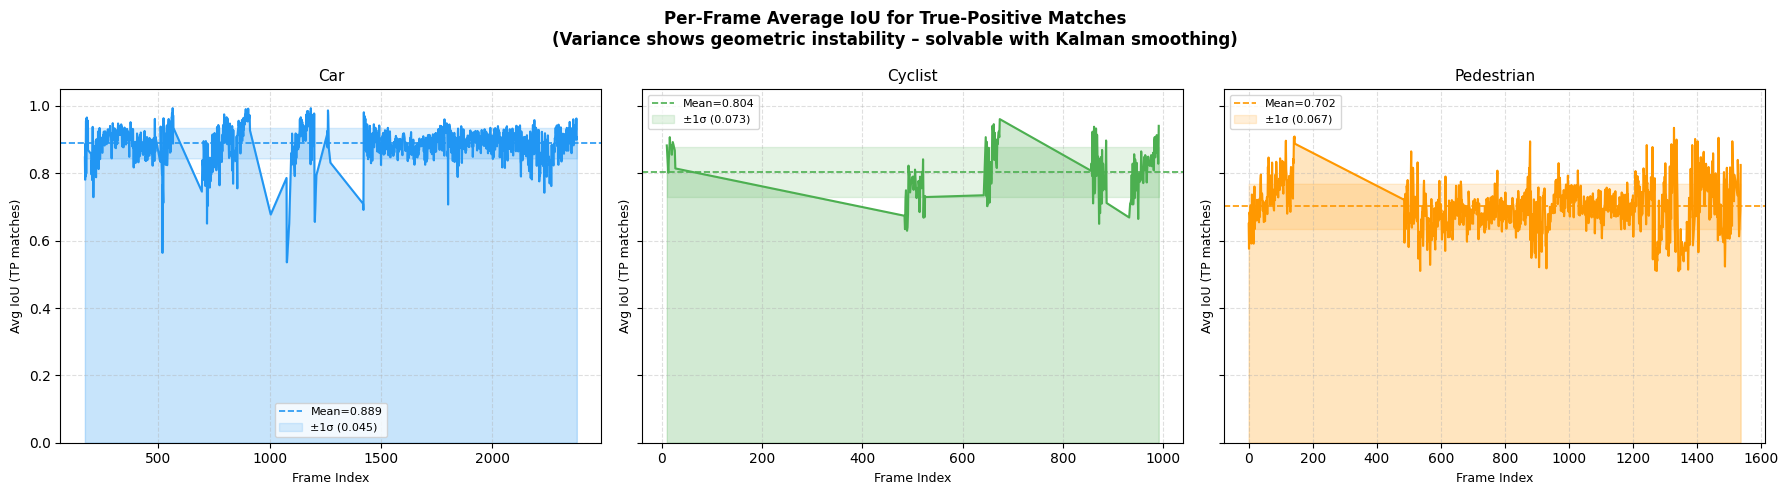

Plot saved to /content/iou_stability.png

Observation: Even for correctly detected objects, IoU varies frame-to-frame.
A Kalman filter would smooth box estimates and reduce this geometric jitter.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ─── Per-frame average IoU stability (TP matches only) ────────────────────
# High frame-to-frame variance reveals that even correctly matched boxes
# are geometrically unstable without temporal smoothing.

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle(
    "Per-Frame Average IoU for True-Positive Matches\n"
    "(Variance shows geometric instability – solvable with Kalman smoothing)",
    fontsize=12, fontweight='bold'
)

classes = ['Car', 'Cyclist', 'Pedestrian']
palette = {'Car': '#2196F3', 'Cyclist': '#4CAF50', 'Pedestrian': '#FF9800'}

for ax, cls in zip(axes, classes):
    cls_df   = frame_metrics_df[
        (frame_metrics_df['class'] == cls) & (frame_metrics_df['tp'] > 0)
    ].sort_values('frame_idx')

    if cls_df.empty:
        ax.set_title(f'{cls}\n(No TP frames)')
        continue

    frames  = cls_df['frame_idx'].values
    ious    = cls_df['avg_iou'].values
    color   = palette[cls]

    ax.fill_between(frames, ious, alpha=0.25, color=color)
    ax.plot(frames, ious, color=color, lw=1.5)

    mean_iou = ious.mean()
    std_iou  = ious.std()
    ax.axhline(mean_iou, color=color, ls='--', lw=1.2,
               label=f'Mean={mean_iou:.3f}')
    ax.fill_between(frames,
                    np.full_like(frames, mean_iou - std_iou, dtype=float),
                    np.full_like(frames, mean_iou + std_iou, dtype=float),
                    color=color, alpha=0.15, label=f'±1σ ({std_iou:.3f})')

    ax.set_title(f'{cls}', fontsize=11)
    ax.set_xlabel('Frame Index', fontsize=9)
    ax.set_ylabel('Avg IoU (TP matches)', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, ls='--', alpha=0.4)

plt.tight_layout()
plt.savefig('/content/iou_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to /content/iou_stability.png")
print("\nObservation: Even for correctly detected objects, IoU varies frame-to-frame.")
print("A Kalman filter would smooth box estimates and reduce this geometric jitter.")